# N-gram language models: a companion notebook

**Human Language Technologies 2026-27, Lecture 04.** Claudio Gallicchio, University of Pisa.

This notebook lets you run the examples of the lecture and check the exercises of the exercise sheet. It follows Chapter 3 of Jurafsky and Martin, *Speech and Language Processing* (3rd edition draft, August 2026), sections 3.1 to 3.5: n-grams, maximum likelihood estimation, perplexity, sampling.

1. Counting n-grams: the *I am Sam* corpus
2. The probability of a sentence, in log space
3. A larger corpus, from your own Python installation
4. Sampling sentences: from unigrams to 4-grams
5. Perplexity, and the zero problem

How to use it: run the cells from top to bottom (Jupyter, VS Code or Google Colab). Only the Python standard library and `matplotlib` are needed, and no internet connection. Everything is written from scratch, in a few lines, so that you can read it; libraries like NLTK do the same in production.

## 1. Counting n-grams

A language model over words needs a corpus split into sentences, each wrapped in the start symbol `<s>` and the end symbol `</s>`. We start with the three-sentence corpus of the lecture. An n-gram model is just a table of counts: for every context of n-1 words, how many times each word followed it. The maximum likelihood estimate of P(w | context) is the count of the n-gram divided by the count of the context.

In [1]:
from collections import Counter, defaultdict
from fractions import Fraction
import math, random

SAM = ["I am Sam", "Sam I am", "I do not like green eggs and ham"]

def sentences_to_tokens(sentences, n):
    """Each sentence becomes a list of tokens with n-1 start symbols and one end symbol."""
    return [["<s>"] * (n - 1) + s.split() + ["</s>"] for s in sentences]

def train(sentences, n):
    """counts[context][word]: how many times word followed the (n-1)-word context."""
    counts = defaultdict(Counter)
    for toks in sentences_to_tokens(sentences, n):
        for i in range(n - 1, len(toks)):
            counts[tuple(toks[i - n + 1:i])][toks[i]] += 1
    return counts

def prob(counts, context, word):
    """Maximum likelihood estimate P(word | context); 0 for unseen n-grams."""
    c = counts.get(tuple(context))
    if not c or word not in c:
        return Fraction(0)
    return Fraction(c[word], sum(c.values()))

bigrams = train(SAM, 2)
for context, word in [("<s>", "I"), ("<s>", "Sam"), ("I", "am"), ("I", "do"), ("am", "Sam"), ("Sam", "</s>"), ("Sam", "I"), ("like", "Sam")]:
    print(f"P({word:4s} | {context:4s}) = {prob(bigrams, [context], word)}")

P(I    | <s> ) = 2/3
P(Sam  | <s> ) = 1/3
P(am   | I   ) = 2/3
P(do   | I   ) = 1/3
P(Sam  | am  ) = 1/2
P(</s> | Sam ) = 1/2
P(I    | Sam ) = 1/2
P(Sam  | like) = 0


These are the six probabilities of the lecture (page 71 of the book), plus two more: P(I | Sam) = 1/2, because *Sam* is followed once by *I* and once by `</s>`, and P(Sam | like) = 0, because the bigram *like Sam* never occurs. The same function gives trigram probabilities, with two start symbols (exercise 3 of the exercise sheet, textbook exercise 3.1).

In [2]:
trigrams = train(SAM, 3)
rows = [(ctx, w, Fraction(c, sum(ws.values()))) for ctx, ws in trigrams.items() for w, c in ws.items()]
print(len(rows), "non-zero trigram probabilities")
for ctx, w, p in sorted(rows, key=lambda r: (-r[2], r[0])):
    print(f"P({w} | {' '.join(ctx)}) = {p}")

16 non-zero trigram probabilities
P(I | <s> Sam) = 1
P(not | I do) = 1
P(am | Sam I) = 1
P(</s> | am Sam) = 1
P(</s> | and ham) = 1
P(like | do not) = 1
P(ham | eggs and) = 1
P(and | green eggs) = 1
P(eggs | like green) = 1
P(green | not like) = 1
P(I | <s> <s>) = 2/3
P(am | <s> I) = 1/2
P(do | <s> I) = 1/2
P(Sam | I am) = 1/2
P(</s> | I am) = 1/2
P(Sam | <s> <s>) = 1/3


## 2. The probability of a sentence

With the Markov assumption, the probability of a sentence is the product of its n-gram probabilities (Eq. 3.9 of the book). Products of many small numbers underflow, so language models work in log space: the log probability of a sentence is the sum of the log probabilities of its n-grams (Eq. 3.13). An unseen n-gram has probability 0 and log probability minus infinity, and it takes the whole sentence down with it.

In [3]:
def sentence_logprob(counts, n, sentence):
    """Natural log probability of a sentence under an n-gram model; -inf if any n-gram is unseen."""
    toks = sentences_to_tokens([sentence], n)[0]
    total = 0.0
    for i in range(n - 1, len(toks)):
        p = prob(counts, toks[i - n + 1:i], toks[i])
        if p == 0:
            return float("-inf")
        total += math.log(p)
    return total

for s in ["I am Sam", "Sam I am", "I am", "Sam I am Sam", "I do not like Sam"]:
    lp = sentence_logprob(bigrams, 2, s)
    p = math.exp(lp) if lp > float("-inf") else 0.0
    print(f"{s:20s} log P = {lp:8.3f}   P = {p:.4f}")

I am Sam             log P =   -2.197   P = 0.1111
Sam I am             log P =   -2.890   P = 0.0556
I am                 log P =   -1.504   P = 0.2222
Sam I am Sam         log P =   -3.584   P = 0.0278
I do not like Sam    log P =     -inf   P = 0.0000


*I am* is not in the corpus and is the most probable of the five: a bigram model recombines the bigrams it has seen. *I do not like Sam* has probability zero because of the single unseen bigram *like Sam* (exercise 2 of the exercise sheet). The Berkeley Restaurant Project sentence of the lecture, with the probabilities of Fig. 3.2:

In [4]:
brp = {("<s>", "i"): 0.25, ("i", "want"): 0.33, ("want", "english"): 0.0011, ("want", "chinese"): 0.0065,
       ("english", "food"): 0.5, ("chinese", "food"): 0.52, ("food", "</s>"): 0.68}

def brp_prob(sentence):
    toks = ["<s>"] + sentence.split() + ["</s>"]
    logp = sum(math.log(brp[(a, b)]) for a, b in zip(toks, toks[1:]))
    return math.exp(logp)

print(f"P(i want english food) = {brp_prob('i want english food'):.6f}")
print(f"P(i want chinese food) = {brp_prob('i want chinese food'):.6f}")
print(f"ratio = {brp_prob('i want chinese food') / brp_prob('i want english food'):.1f}")

P(i want english food) = 0.000031
P(i want chinese food) = 0.000190
ratio = 6.1


## 3. A larger corpus, from your own Python installation

Three sentences do not make a language model. We need a corpus of tens of thousands of words, without downloading anything: every Python installation carries one, the documentation strings of the standard library. It is English prose of a very particular genre, which is exactly what section 3.5 of the book is about: the model learns the genre of its training corpus.

We collect the docstrings of about a hundred modules, split them into sentences at periods, question marks and exclamation points, drop the code examples, lower-case everything and treat punctuation marks as words, as the book does for Shakespeare (Fig. 3.4). The exact numbers below depend on your Python version.

In [5]:
import importlib, inspect, re

MODULES = """os re json collections itertools random statistics textwrap datetime pathlib logging argparse csv math
functools string heapq bisect difflib shutil glob fnmatch tempfile time calendar decimal fractions operator copy pprint enum
typing dataclasses abc contextlib unittest doctest pdb timeit zipfile tarfile gzip hashlib hmac secrets struct codecs io
threading queue subprocess socket email html http.client urllib.parse xml.etree.ElementTree sqlite3 pickle shelve configparser
getpass platform sys gc inspect ast tokenize keyword warnings traceback locale gettext cmd shlex optparse uuid ipaddress base64
binascii colorsys wave array weakref types numbers cmath select signal mmap asyncio concurrent.futures multiprocessing sched
graphlib zoneinfo smtplib imaplib ftplib webbrowser turtle site sysconfig venv zipapp runpy importlib pkgutil dis pickletools
filecmp linecache stat fileinput netrc plistlib mailbox mimetypes quopri unicodedata reprlib pydoc atexit errno ctypes trace
tracemalloc bdb code codeop symtable token tabnanny py_compile compileall zlib bz2 lzma""".split()

def module_text(name):
    """The docstring of a module and of its public functions and classes."""
    try:
        mod = importlib.import_module(name)
    except Exception:
        return ""
    parts = [inspect.getdoc(mod) or ""]
    for member, obj in inspect.getmembers(mod):
        if member.startswith("_") or not (inspect.isfunction(obj) or inspect.isclass(obj) or inspect.isbuiltin(obj)):
            continue
        d = inspect.getdoc(obj)
        if d and (getattr(obj, "__module__", None) or name).split(".")[0] == name.split(".")[0]:
            parts.append(d)
    return "\n".join(parts)

def to_sentences(text):
    """Lower-case, split at sentence-final punctuation, keep punctuation marks as words."""
    text = re.sub(r"\s+", " ", text.lower())
    out = []
    for s in re.split(r"(?<=[.!?])\s+", text):
        if ">>>" in s or "\\" in s:      # skip doctest examples and escaped strings
            continue
        toks = re.findall(r"[a-z][a-z'_-]*|[0-9]+|[^\sa-z0-9]", s)
        if len(toks) >= 3 and sum(t.isalpha() for t in toks) >= 0.7 * len(toks):   # mostly words, not code
            out.append(" ".join(toks))
    return out

texts = {m: to_sentences(module_text(m)) for m in MODULES}
texts = {m: s for m, s in texts.items() if s}
# held-out modules for testing: every tenth module; the rest is the training corpus
test_modules = sorted(texts)[::10]
train_sents = [s for m, ss in texts.items() if m not in test_modules for s in ss]
test_sents = [s for m in test_modules for s in texts[m]]
N_train = sum(len(s.split()) for s in train_sents)
V = len(set(w for s in train_sents for w in s.split()))
print(f"{len(texts)} modules, {len(train_sents)} training sentences, N = {N_train} tokens, V = {V} types")
print(f"{len(test_sents)} test sentences from {len(test_modules)} held-out modules: {', '.join(test_modules)}")
print()
for s in random.Random(3).sample(train_sents, 4):
    print("-", s)

133 modules, 2904 training sentences, N = 49759 tokens, V = 4006 types
609 test sentences from 14 held-out modules: abc, calendar, configparser, doctest, gc, http.client, logging, optparse, py_compile, select, statistics, textwrap, unittest, zipfile

- this can be used to efficiently compute the digests of datas that share a common initial substring .
- this can be overridden in sitecustomize , usercustomize or pythonstartup .
- this returns true when obj is a future instance or is advertising itself as duck-type compatible by setting _ asyncio_future_blocking .
- removes the pack format from the registry .


The most frequent words of this corpus, and how sparse the bigram table is. With N tokens there are at most N - 1 distinct bigrams, out of V squared possible ones (exercise 11 of the exercise sheet).

In [6]:
uni = train(train_sents, 1)[()]
print("most frequent words:", ", ".join(f"{w} ({c})" for w, c in uni.most_common(15)))
bi = train(train_sents, 2)
distinct_bigrams = sum(len(c) for c in bi.values())
print(f"distinct bigrams: {distinct_bigrams:,} out of V^2 = {V**2:,} possible: {100 * distinct_bigrams / V**2:.2f} % of the table is non-zero")

most frequent words: . (3162), the (3014), </s> (2904), a (1449), , (1438), is (1125), to (1071), of (935), and (701), ( (654), ) (648), for (612), in (571), be (542), if (540)
distinct bigrams: 22,224 out of V^2 = 16,048,036 possible: 0.14 % of the table is non-zero


## 4. Sampling sentences

To see what a model has learned, sample from it (section 3.4): start from the context of n-1 start symbols, draw the next word according to the model's distribution for that context, shift the context, and stop at `</s>`. The unigram sentences are word salad; the bigram ones have local coherence; the 4-gram ones copy the docstrings almost verbatim, as the 4-gram Shakespeare of Fig. 3.4 copies King John. The random seed makes the output reproducible; change it to get other sentences.

In [7]:
def sample_sentence(counts, n, rng, max_len=40):
    context = ["<s>"] * (n - 1)
    words = []
    while len(words) < max_len:
        c = counts[tuple(context)]
        word = rng.choices(list(c.keys()), weights=list(c.values()))[0]
        if word == "</s>":
            break
        words.append(word)
        context = (context + [word])[1:] if n > 1 else []
    return " ".join(words) if words else "(empty sentence: </s> was drawn first)"

models = {n: train(train_sents, n) for n in (1, 2, 3, 4)}
rng = random.Random(2026)
for n in (1, 2, 3, 4):
    print(f"--- {n}-gram")
    for _ in range(3):
        print(sample_sentence(models[n], n, rng))

--- 1-gram
(empty sentence: </s> was drawn first)
no this indicate
( been in member signal mapping classes random all , instance
--- 2-gram
file is created by python object . 9 .
zdict the result is to be added to set by the encoding , then , relative to the case no tty is rfc_ 4122 variant is no command line of the current stack traces .
return a single instance , this object creation to ` code object , unless ' b' to instantiate a slice assignment ) ) on platforms where file .
--- 3-gram
an ftp client class .
see help ( thing ) on a variable .
return a temporary file .
--- 4-gram
you can concatenate ordinary characters , so last matches the string ' last' .
see individual fields' descriptions for details .
- : attr : ` line ` the text from the linecache module for the list of subdirectories is retrieved before the tuples for the directory and everything contained in it are processed .


Is a sampled 4-gram sentence in the training corpus? Check with the cell below: most of them are, or differ from a training sentence by a few words. This is overfitting to the training corpus, section 3.5.

In [8]:
train_set = set(train_sents)
rng = random.Random(7)
for n in (2, 3, 4):
    copied = sum(sample_sentence(models[n], n, rng) in train_set for _ in range(200))
    print(f"{n}-gram: {copied} of 200 sampled sentences are training sentences, copied verbatim")

2-gram: 0 of 200 sampled sentences are training sentences, copied verbatim
3-gram: 11 of 200 sampled sentences are training sentences, copied verbatim
4-gram: 76 of 200 sampled sentences are training sentences, copied verbatim


## 5. Perplexity

The perplexity of a model on a test set is the inverse probability of the test set, normalized by the number of tokens (Eq. 3.15): in log space, exp of minus the average log probability per token. We count `</s>` in N but not `<s>`, as the book does. On its own training corpus the model is never surprised by an unseen n-gram, and perplexity drops quickly with n: the model fits the training data better and better. That is not evaluation, that is training on the test set.

In [9]:
def perplexity(counts, n, sentences):
    """Perplexity of an n-gram model on a list of sentences; also returns the number of unseen n-grams."""
    logp, N, zeros = 0.0, 0, 0
    for toks in sentences_to_tokens(sentences, n):
        for i in range(n - 1, len(toks)):
            p = prob(counts, toks[i - n + 1:i], toks[i])
            N += 1
            if p == 0:
                zeros += 1
            else:
                logp += math.log(p)
    return (math.exp(-logp / N) if zeros == 0 else float("inf")), zeros, N

for n in (1, 2, 3, 4, 5):
    pp, zeros, N = perplexity(train(train_sents, n), n, train_sents)
    print(f"{n}-gram model, perplexity on the TRAINING sentences: {pp:8.2f}   (N = {N}, unseen n-grams: {zeros})")

1-gram model, perplexity on the TRAINING sentences:   385.56   (N = 52663, unseen n-grams: 0)
2-gram model, perplexity on the TRAINING sentences:    20.24   (N = 52663, unseen n-grams: 0)


3-gram model, perplexity on the TRAINING sentences:     3.21   (N = 52663, unseen n-grams: 0)
4-gram model, perplexity on the TRAINING sentences:     1.78   (N = 52663, unseen n-grams: 0)


5-gram model, perplexity on the TRAINING sentences:     1.59   (N = 52663, unseen n-grams: 0)


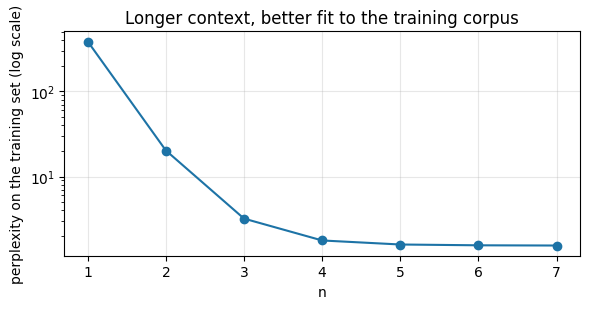

In [10]:
import matplotlib.pyplot as plt

ns = range(1, 8)
pps = [perplexity(train(train_sents, n), n, train_sents)[0] for n in ns]
plt.figure(figsize=(6, 3.2))
plt.plot(list(ns), pps, marker="o", color="#1D73A6")
plt.yscale("log")
plt.xlabel("n"); plt.ylabel("perplexity on the training set (log scale)")
plt.title("Longer context, better fit to the training corpus")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

On the held-out modules the picture is different: many test n-grams never occurred in training, their maximum likelihood probability is zero, and perplexity cannot be computed at all. This is the zero problem of section 3.5, and smoothing (section 3.6) is the remedy. Even the unigram model has zeros here, because a docstring of a held-out module can use a word that no other module uses.

In [11]:
for n in (1, 2, 3):
    pp, zeros, N = perplexity(train(train_sents, n), n, test_sents)
    print(f"{n}-gram model on the HELD-OUT sentences: perplexity = {pp}, {zeros} of {N} test n-grams have probability zero ({100 * zeros / N:.1f} %)")

1-gram model on the HELD-OUT sentences: perplexity = inf, 913 of 11364 test n-grams have probability zero (8.0 %)
2-gram model on the HELD-OUT sentences: perplexity = inf, 5192 of 11364 test n-grams have probability zero (45.7 %)
3-gram model on the HELD-OUT sentences: perplexity = inf, 8648 of 11364 test n-grams have probability zero (76.1 %)


To see perplexity as a weighted average branching factor, the three-color language of the lecture (section 3.3.1): model A gives each color probability 1/3, model B gives 0.8 to red. And the digits of textbook exercise 3.12 (exercise 8 of the exercise sheet).

In [12]:
def unigram_perplexity(probs, test):
    return math.exp(-sum(math.log(probs[w]) for w in test) / len(test))

T = "red red red red blue".split()
A = {"red": 1/3, "blue": 1/3, "green": 1/3}
B = {"red": 0.8, "blue": 0.1, "green": 0.1}
print(f"perplexity of A on T: {unigram_perplexity(A, T):.3f}   perplexity of B on T: {unigram_perplexity(B, T):.3f}")

digits = {str(d): (91 if d == 0 else 1) / 100 for d in range(10)}
print(f"textbook exercise 3.12: {unigram_perplexity(digits, '0 0 0 0 0 3 0 0 0 0'.split()):.3f}")

perplexity of A on T: 3.000   perplexity of B on T: 1.895
textbook exercise 3.12: 1.725


## 6. What to do next

- The exercise sheet of this lecture: exercises 2, 3, 4, 7, 8 and 9 can be checked with `prob`, `sentence_logprob` and `perplexity`; exercises 10 and 11 with `sample_sentence` and the sparsity count of section 3.
- Textbook exercises 3.8 to 3.11 ask for a program that computes unsmoothed unigrams and bigrams, compares two corpora, generates random sentences and computes perplexity: this notebook is a starting point. Try it on a text of your choice, for example a public-domain novel, and compare its samples with the ones from the Python docstrings.
- Textbook exercise 3.5: remove the end symbol and check that the probabilities of all two-word sentences sum to one, and so do those of all three-word sentences.